# Face Restoration (U-Net) — extended training

In [ ]:
import os
import sys
from pathlib import Path


PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "train.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the Face-Restoration-Deep-Learning project directory")
DATASET_ZIP = Path("dataset.zip")
EXTRACT_DIR = Path("data/extracted")
RAW_DIR = EXTRACT_DIR  
DATA_DIR = Path("data/extended_run")
ALIGNED_DIR = DATA_DIR / "aligned"
RESULTS_DIR = Path("results/extended_run")
CHECKPOINT_DIR = Path("checkpoints/extended_run")


MAX_RAW_IMAGES = 512
MAX_TRAIN_SAMPLES = 0   
PHASE1_EPOCHS = 4
PHASE2_EPOCHS = 6
BATCH_SIZE = 4

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
for key, value in {
    "DATA_DIR": DATA_DIR, "RAW_DIR": RAW_DIR, "ALIGNED_DIR": ALIGNED_DIR,
    "RESULTS_DIR": RESULTS_DIR, "CHECKPOINT_DIR": CHECKPOINT_DIR,
    "MAX_RAW_IMAGES": MAX_RAW_IMAGES, "MAX_TRAIN_SAMPLES": MAX_TRAIN_SAMPLES,
    "PHASE1_EPOCHS": PHASE1_EPOCHS, "PHASE2_EPOCHS": PHASE2_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE, "NUM_WORKERS": 0,
}.items():
    os.environ[key] = str(value)
print(f"Training setup: {MAX_RAW_IMAGES} input images, {PHASE1_EPOCHS}+{PHASE2_EPOCHS} epochs, batch size {BATCH_SIZE}")

Training setup: 512 input images, 4+6 epochs, batch size 4


In [ ]:
import shutil
import subprocess
import zipfile
from PIL import Image

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
if not DATASET_ZIP.is_file():
    raise FileNotFoundError(f"Required image archive is missing: {DATASET_ZIP}")

 
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True)
if zipfile.is_zipfile(DATASET_ZIP):
    with zipfile.ZipFile(DATASET_ZIP) as zf:
        zf.extractall(EXTRACT_DIR)
    archive_status = "standard ZIP extraction"
else:
    seven_zip = shutil.which("7z")
    if seven_zip is None:
        raise RuntimeError(f"{DATASET_ZIP} is incomplete or corrupt; install 7z to recover intact entries, or replace this ZIP")
    
    recovered = subprocess.run([seven_zip, "x", "-y", f"-o{EXTRACT_DIR}", str(DATASET_ZIP)], capture_output=True, text=True)
    archive_status = f"7z recovery (exit code {recovered.returncode})"
    if recovered.returncode:
        print("Archive warning: ZIP is truncated; intact images were recovered with 7z.")

image_files = sorted(p for p in EXTRACT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
invalid = []
for image_path in image_files:
    try:
        with Image.open(image_path) as image:
            image.load()  
        if image_path.suffix.lower() in {".jpg", ".jpeg"} and image_path.read_bytes()[-2:] != b"\xff\xd9":
            raise ValueError("missing JPEG end marker")
    except Exception as exc:
        invalid.append((image_path.relative_to(EXTRACT_DIR).as_posix(), str(exc)))
        image_path.unlink()   
image_files = [p for p in image_files if p.exists()]
if not image_files:
    raise RuntimeError(f"No decodable images found in {DATASET_ZIP}; check the archive contents")
print("Archive status:", archive_status)
print("Images extracted:", len(image_files))
print("Rejected incomplete images:", len(invalid))

Archive warning: ZIP is truncated; intact images were recovered with 7z.


Archive status: 7z recovery (exit code 2)
Images extracted: 3092
Rejected incomplete images: 1


In [ ]:
from collections import Counter
from PIL import Image

print("=== Extracted dataset, before the pilot split ===")
print("Total valid images:", len(image_files))
print("Extensions:", dict(Counter(p.suffix.lower() for p in image_files)))
folder_counts = Counter(p.parent.relative_to(EXTRACT_DIR).as_posix() for p in image_files)
print("Image-bearing folders:", dict(folder_counts))
print("Top-level folders:", sorted(p.name for p in EXTRACT_DIR.iterdir() if p.is_dir()))
with Image.open(image_files[0]) as sample:
    print("Example size/mode:", sample.size, sample.mode)

labelled_classes = 0 if len(folder_counts) == 1 and next(iter(folder_counts)) in {"output", "."} else len(folder_counts)
print("Identifiable labelled classes:", labelled_classes)
if labelled_classes == 0:
    print("No class labels are present; restoration metrics are used instead of accuracy or a confusion matrix.")

=== Extracted dataset, before the pilot split ===
Total valid images: 3092
Extensions: {'.jpg': 3092}
Image-bearing folders: {'output': 3092}
Top-level folders: ['output']
Example size/mode: (128, 128) RGB
Identifiable labelled classes: 0
No class labels are present; restoration metrics are used instead of accuracy or a confusion matrix.


In [ ]:
from src.align import run_alignment_and_split


if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
splits = run_alignment_and_split(
    src_folder=str(RAW_DIR), aligned_folder=str(ALIGNED_DIR),
    output_dir=str(DATA_DIR), max_raw_images=MAX_RAW_IMAGES,
)
print("Split sizes:", {name: len(files) for name, files in splits.items()})

Aligning raw images on cpu...
Found 512 raw images to process.


Alignment done. MTCNN=511, fallback_resize=1, failed=0
Data split completed: Train=384, Val=76, Test=52
Split sizes: {'train': 384, 'val': 76, 'test': 52}


In [5]:
import warnings
warnings.filterwarnings("ignore", message="ShiftScaleRotate is a special case of Affine transform.*")
from train import train

train()

Using device: mps
Train samples: 384 | Val samples: 76
Batch size: 4 | Phase1 epochs: 4 | Phase2 epochs: 6

>>> Phase 1: L1 Loss Warm-up (4 Epochs)


Phase 1 - Epoch [1/4] Train: 0.19655 | Val: 0.07579


Phase 1 - Epoch [2/4] Train: 0.06098 | Val: 0.05046


Phase 1 - Epoch [3/4] Train: 0.04862 | Val: 0.04443


Phase 1 - Epoch [4/4] Train: 0.04229 | Val: 0.03837

>>> Phase 2: L1 + Identity Loss (6 Epochs)


...

Phase 2 - Epoch [3/6] Train: 0.03337 | Val: 0.03101


Phase 2 - Epoch [4/6] Train: 0.03278 | Val: 0.02742


Phase 2 - Epoch [5/6] Train: 0.03213 | Val: 0.02976


Phase 2 - Epoch [6/6] Train: 0.03083 | Val: 0.02988

Model checkpoint saved.


Training curve saved.
Training metrics saved.
Approximate runtime: 7.78 minutes


In [6]:
from evaluate import evaluate

evaluate()

Evaluating model on test dataset (52 images) using mps...



--- Test Set Evaluation Metrics ---
PSNR: 27.8432
SSIM: 0.8361
Embedding Distance: 0.0005
Evaluation metrics saved as JSON and CSV.


Visual comparison saved.
Prediction samples saved.


--- Training loss curve ---


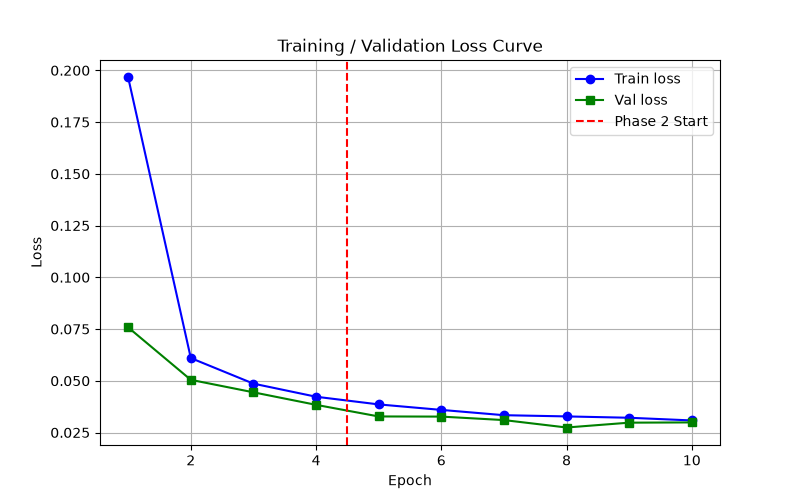


--- Qualitative comparison ---


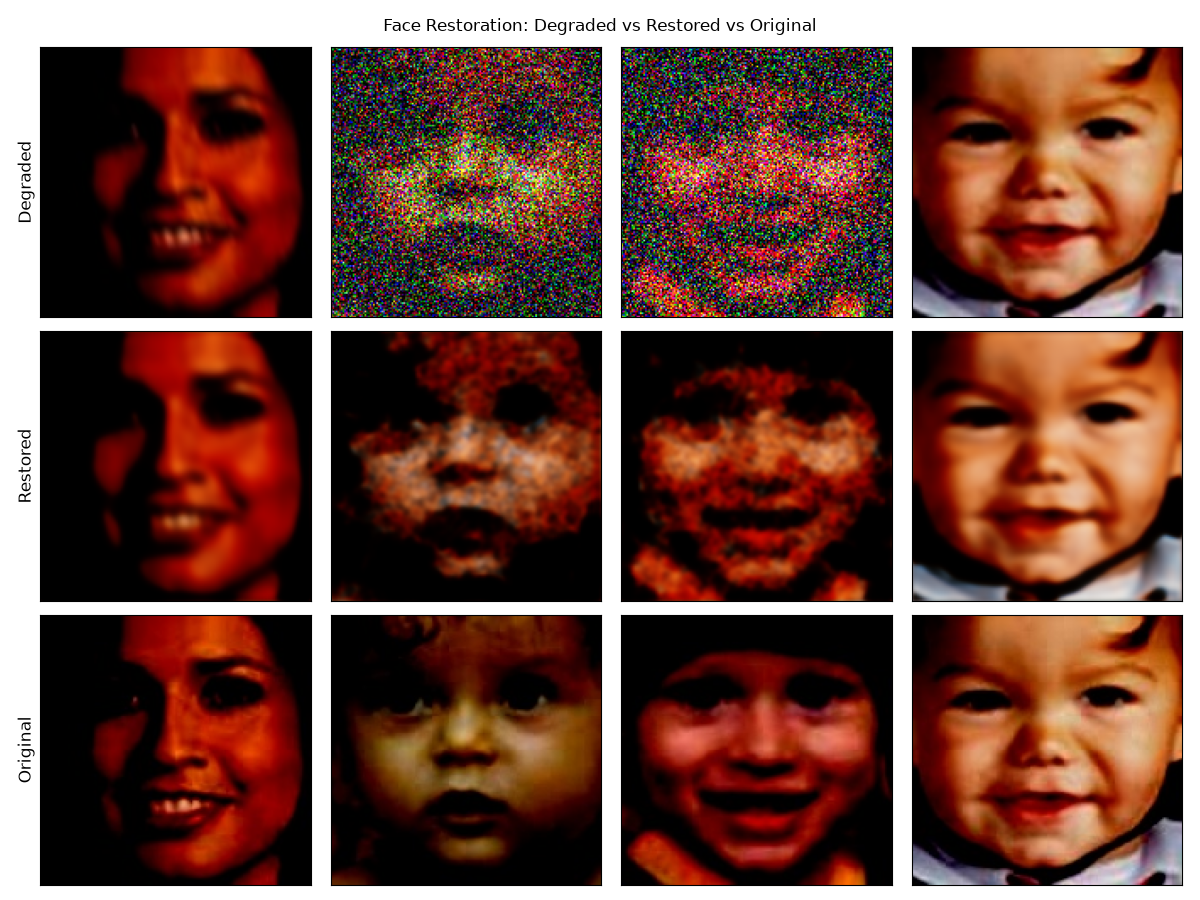


--- Prediction samples ---


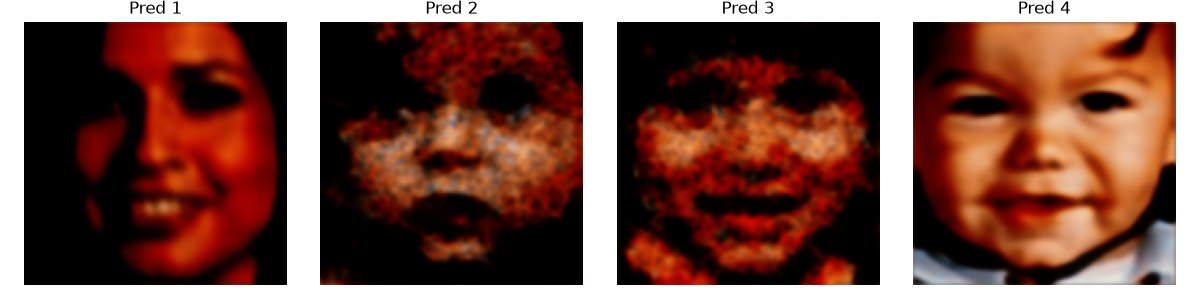


--- Training metrics ---
{
  "device": "mps",
  "n_train": 384,
  "n_val": 76,
  "batch_size": 4,
  "phase1_epochs": 4,
  "phase2_epochs": 6,
  "total_epochs": 10,
  "final_train_loss": 0.03083022664456318,
  "final_val_loss": 0.029879325412605937,
  "elapsed_seconds": 466.70805382728577,
  "checkpoint": "face_restoration_unet.pth"
}

--- Eval metrics ---
{
  "n_test": 52,
  "psnr": 27.843205254966065,
  "ssim": 0.8360725045204163,
  "embedding_distance": 0.00046795660902996763,
  "psnr_std": 3.735358926882078,
  "ssim_std": 0.08626053482294083
}

Saved training metrics, evaluation metrics, plots, predictions, and model weights.

This is image restoration with no class labels: accuracy curve and confusion matrix do not apply.


In [7]:
import json
from IPython.display import Image, display

print("--- Training loss curve ---")
display(Image(str(RESULTS_DIR / "training_curve.png")))

print("\n--- Qualitative comparison ---")
display(Image(str(RESULTS_DIR / "qualitative_comparison.png")))

print("\n--- Prediction samples ---")
display(Image(str(RESULTS_DIR / "prediction_samples.png")))

print("\n--- Training metrics ---")
with open(RESULTS_DIR / "training_metrics.json") as f:
    train_metrics = json.load(f)
print(json.dumps({k: v for k, v in train_metrics.items() if k != "history"}, indent=2))

print("\n--- Eval metrics ---")
with open(RESULTS_DIR / "eval_metrics.json") as f:
    eval_metrics = json.load(f)
print(json.dumps(eval_metrics, indent=2))

print("\nSaved training metrics, evaluation metrics, plots, predictions, and model weights.")

print("\nThis is image restoration with no class labels: accuracy curve and confusion matrix do not apply.")